In [1]:

!pip install -q insightface==0.7.3
!pip install -q onnxruntime
!pip install -q opencv-python-headless
!pip install -q numpy pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 439.5/439.5 kB 9.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 126.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 125.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 9.7 MB/s eta 0:00:00


In [2]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
import os
from google.colab import files
import pickle
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple
import shutil
from datetime import datetime
import json
from IPython.display import display, clear_output
from PIL import Image

# Setup paths
BASE_PATH = '/content/drive/MyDrive/face_recognition_system'
DATASET_PATH = f'{BASE_PATH}/dataset'
EMBEDDINGS_PATH = f'{BASE_PATH}/embeddings'
MATCHED_PATH = f'{BASE_PATH}/matched_images'

# Create directories
for path in [BASE_PATH, DATASET_PATH, EMBEDDINGS_PATH, MATCHED_PATH]:
    os.makedirs(path, exist_ok=True)

print(" Directories created!")

 Directories created!


In [3]:
# Initialize face recognition model
print("Loading face recognition model...")
app = FaceAnalysis(
    name='buffalo_l',
    providers=['CPUExecutionProvider']  # Use CPU to avoid CUDA issues
)
app.prepare(ctx_id=0, det_size=(640, 640))
print(" Model loaded successfully!")

Loading face recognition model...
download_path: /root/.insightface/models/buffalo_l


100%|██████████| 281857/281857 [00:03<00:00, 73772.83KB/s]


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /root/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det-size: (640, 640)
 Model loade

In [4]:
class FaceRecognitionSystem:
    def __init__(self):
        self.dataset_path = DATASET_PATH
        self.embeddings_path = EMBEDDINGS_PATH
        self.database_file = os.path.join(EMBEDDINGS_PATH, 'face_database.pkl')
        self.face_database = {}
        self.similarity_threshold = 0.4  # Lower threshold for better matching
        self.load_or_create_database()

    def load_or_create_database(self):
        """Load existing database or create new one"""
        if os.path.exists(self.database_file):
            try:
                with open(self.database_file, 'rb') as f:
                    self.face_database = pickle.load(f)
                print(f" Database loaded: {len(self.face_database)} people")
            except:
                print("Creating new database...")
                self.face_database = {}
                self.build_database()
        else:
            print("No existing database found. Building from dataset...")
            self.build_database()

    def build_database(self):
        """Build database from existing images in dataset"""
        if not os.path.exists(self.dataset_path):
            print("No dataset folder found. Creating empty database.")
            self.face_database = {}
            self.save_database()
            return

        folders = [f for f in os.listdir(self.dataset_path)
                  if os.path.isdir(os.path.join(self.dataset_path, f)) and f.isdigit()]

        if not folders:
            print("No folders found in dataset. Ready for new faces!")
            self.face_database = {}
            self.save_database()
            return

        print(f"Found {len(folders)} folders. Building embeddings...")

        for folder in folders:
            folder_path = os.path.join(self.dataset_path, folder)
            embeddings = []
            image_paths = []

            for img_file in os.listdir(folder_path):
                if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                    img_path = os.path.join(folder_path, img_file)
                    print(f"Processing: {folder}/{img_file}")

                    # Extract embedding
                    emb = self.extract_embedding(img_path)
                    if emb is not None:
                        embeddings.append(emb)
                        image_paths.append(img_path)

            if embeddings:
                self.face_database[folder] = {
                    'embeddings': embeddings,
                    'avg_embedding': np.mean(embeddings, axis=0),
                    'image_paths': image_paths,
                    'num_images': len(embeddings)
                }
                print(f" Folder {folder}: {len(embeddings)} embeddings")

        self.save_database()
        print(f" Database built with {len(self.face_database)} people")

    def extract_embedding(self, image_path):
        """Extract face embedding from image"""
        try:
            img = cv2.imread(image_path)
            if img is None:
                print(f"Cannot read image: {image_path}")
                return None

            faces = app.get(img)
            if len(faces) > 0:
                return faces[0].embedding
            else:
                print(f"No face found in: {image_path}")
                return None
        except Exception as e:
            print(f"Error extracting embedding: {e}")
            return None

    def save_database(self):
        """Save database to disk"""
        with open(self.database_file, 'wb') as f:
            pickle.dump(self.face_database, f)
        print(" Database saved")

    def search_face(self, image_array):
        """Search for face in database"""
        try:
            # Detect faces
            faces = app.get(image_array)

            if len(faces) == 0:
                print(" No face detected in image")
                return None, 0.0, "No face detected"

            print(f" Detected {len(faces)} face(s)")

            # Get embedding
            test_embedding = faces[0].embedding

            if len(self.face_database) == 0:
                print("Database is empty")
                return None, 0.0, "Database empty"

            # Search in database
            best_match = None
            best_score = 0.0
            all_scores = {}

            for folder_id, data in self.face_database.items():
                # Compare with average embedding
                similarity = np.dot(test_embedding, data['avg_embedding']) / (
                    np.linalg.norm(test_embedding) * np.linalg.norm(data['avg_embedding'])
                )

                all_scores[folder_id] = similarity

                if similarity > best_score:
                    best_score = similarity
                    best_match = folder_id

            # Print all scores for debugging
            print("\n Similarity Scores:")
            for fid, score in sorted(all_scores.items(), key=lambda x: x[1], reverse=True):
                print(f"  Folder {fid}: {score:.3f}")

            if best_score >= self.similarity_threshold:
                return best_match, best_score, "Match found"
            else:
                return None, best_score, f"Below threshold ({self.similarity_threshold})"

        except Exception as e:
            print(f"Error in search_face: {e}")
            return None, 0.0, str(e)

    def add_new_person(self, image_array):
        """Add new person to database"""
        # Get next folder ID
        existing = [int(f) for f in self.face_database.keys()]
        if existing:
            next_id = str(max(existing) + 1)
        else:
            next_id = "1"

        # Create folder
        folder_path = os.path.join(self.dataset_path, next_id)
        os.makedirs(folder_path, exist_ok=True)

        # Save image
        img_name = f"{next_id}.1.jpg"
        img_path = os.path.join(folder_path, img_name)
        cv2.imwrite(img_path, image_array)

        # Extract embedding
        faces = app.get(image_array)
        if len(faces) > 0:
            embedding = faces[0].embedding

            # Add to database
            self.face_database[next_id] = {
                'embeddings': [embedding],
                'avg_embedding': embedding,
                'image_paths': [img_path],
                'num_images': 1
            }

            self.save_database()
            print(f" New person added: Folder {next_id}")
            return next_id
        else:
            print(" No face found")
            return None

    def update_person(self, folder_id, image_array):
        """Update existing person with new image"""
        folder_path = os.path.join(self.dataset_path, folder_id)
        os.makedirs(folder_path, exist_ok=True)

        # Get next image number
        existing_images = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
        next_num = len(existing_images) + 1

        # Save image
        img_name = f"{folder_id}.{next_num}.jpg"
        img_path = os.path.join(folder_path, img_name)
        cv2.imwrite(img_path, image_array)

        # Save to matched folder
        matched_folder = os.path.join(MATCHED_PATH, folder_id)
        os.makedirs(matched_folder, exist_ok=True)
        matched_path = os.path.join(matched_folder, img_name)
        cv2.imwrite(matched_path, image_array)

        # Extract embedding
        faces = app.get(image_array)
        if len(faces) > 0:
            embedding = faces[0].embedding

            # Update database
            self.face_database[folder_id]['embeddings'].append(embedding)
            self.face_database[folder_id]['image_paths'].append(img_path)
            self.face_database[folder_id]['num_images'] += 1
            self.face_database[folder_id]['avg_embedding'] = np.mean(
                self.face_database[folder_id]['embeddings'], axis=0
            )

            self.save_database()
            print(f" Updated Folder {folder_id} with new image: {img_name}")
            return True
        return False

# Initialize system
face_system = FaceRecognitionSystem()

 Database loaded: 9 people


 UPLOAD IMAGE FOR FACE RECOGNITION


Saving Robert Downey Jr_9.jpg to Robert Downey Jr_9.jpg

 Uploaded Image:


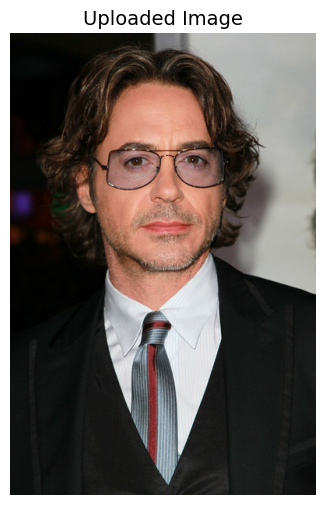


 PROCESSING IMAGE...
 Detected 1 face(s)

 Similarity Scores:
  Folder 11: 0.652
  Folder 1: 0.111
  Folder 2: 0.040
  Folder 10: 0.034
  Folder 6: 0.032
  Folder 9: 0.013
  Folder 8: 0.003
  Folder 5: 0.000
  Folder 4: -0.001
  Folder 3: -0.024
  Folder 7: -0.089

 RESULTS:
----------------------------------------
Status: Match found
Best Score: 0.652
Threshold: 0.400

 MATCH FOUND!
 MATCHED FOLDER: 11
 CONFIDENCE: 65.2%
 Database saved
 Updated Folder 11 with new image: 11.2.jpg


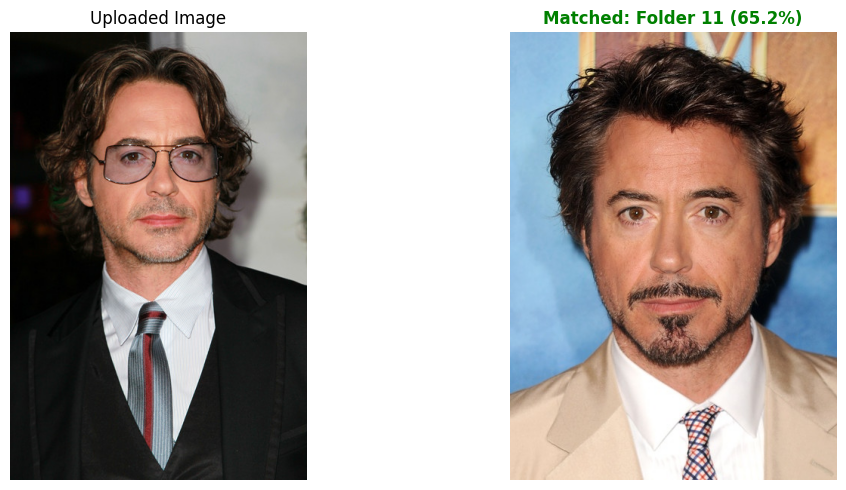


 RETURNED FOLDER ID: 11


In [13]:
def process_uploaded_image():
    """Simple function to upload and process image"""
    print("=" * 60)
    print(" UPLOAD IMAGE FOR FACE RECOGNITION")
    print("=" * 60)

    # Upload image
    uploaded = files.upload()

    if not uploaded:
        print("No image uploaded")
        return None

    # Get first uploaded file
    filename = list(uploaded.keys())[0]

    # Read image
    image_array = cv2.imdecode(
        np.frombuffer(uploaded[filename], np.uint8),
        cv2.IMREAD_COLOR
    )

    import os
    cv2.imwrite(os.path.join("drive/MyDrive/face_recognition_system/unknown_images", filename), image_array)

    if image_array is None:
        print(" Could not read image")
        return None

    # Display uploaded image
    print("\n Uploaded Image:")
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
    plt.title("Uploaded Image", fontsize=14)
    plt.axis('off')
    plt.show()

    print("\n" + "=" * 60)
    print(" PROCESSING IMAGE...")
    print("=" * 60)

    # Search face in database
    matched_folder, score, status = face_system.search_face(image_array)

    print(f"\n RESULTS:")
    print("-" * 40)
    print(f"Status: {status}")
    print(f"Best Score: {score:.3f}")
    print(f"Threshold: {face_system.similarity_threshold:.3f}")

    if matched_folder:
        # MATCHED
        print(f"\n MATCH FOUND!")
        print(f" MATCHED FOLDER: {matched_folder}")
        print(f" CONFIDENCE: {score:.1%}")

        # Update person
        face_system.update_person(matched_folder, image_array)

        # Show comparison
        if face_system.face_database[matched_folder]['image_paths']:
            ref_img = cv2.imread(face_system.face_database[matched_folder]['image_paths'][0])

            fig, axes = plt.subplots(1, 2, figsize=(12, 5))

            axes[0].imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
            axes[0].set_title('Uploaded Image', fontsize=12)
            axes[0].axis('off')

            axes[1].imshow(cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB))
            axes[1].set_title(f'Matched: Folder {matched_folder} ({score:.1%})',
                            fontsize=12, color='green', fontweight='bold')
            axes[1].axis('off')

            plt.tight_layout()
            plt.show()

        print("\n" + "=" * 60)
        print(f" RETURNED FOLDER ID: {matched_folder}")
        print("=" * 60)

        return matched_folder

    else:
        # NOT MATCHED
        print(f"\n NO MATCH FOUND (Best score: {score:.3f})")
        print("Creating new person...")

        new_folder = face_system.add_new_person(image_array)

        if new_folder:
            print(f"\n NEW PERSON CREATED")
            print(f" NEW FOLDER ID: {new_folder}")

            plt.figure(figsize=(8, 6))
            plt.imshow(cv2.cvtColor(image_array, cv2.COLOR_BGR2RGB))
            plt.title(f"New Person: Folder {new_folder}", fontsize=14, color='blue')
            plt.axis('off')
            plt.show()

            print("\n" + "=" * 60)
            print(f" RETURNED FOLDER ID: {new_folder}")
            print("=" * 60)

            return new_folder
        else:
            print(" Failed to create new person")
            return None

# Run the recognition
result = process_uploaded_image()

In [14]:
def show_database_info():
    """Show current database information"""
    print("\n" + "=" * 60)
    print(" DATABASE INFORMATION")
    print("=" * 60)

    if face_system.face_database:
        print(f"Total People: {len(face_system.face_database)}")
        print(f"Similarity Threshold: {face_system.similarity_threshold:.1%}")

        print("\n Folders in Database:")
        for folder_id in sorted(face_system.face_database.keys(), key=int):
            data = face_system.face_database[folder_id]
            print(f"  Folder {folder_id}: {data['num_images']} images")

        # Check actual folders
        print("\n Actual Folders in Dataset:")
        if os.path.exists(DATASET_PATH):
            folders = [f for f in os.listdir(DATASET_PATH)
                      if os.path.isdir(os.path.join(DATASET_PATH, f))]
            for folder in sorted(folders, key=lambda x: int(x) if x.isdigit() else 0):
                folder_path = os.path.join(DATASET_PATH, folder)
                images = [f for f in os.listdir(folder_path) if f.endswith('.jpg')]
                print(f"  Folder {folder}: {len(images)} images")
    else:
        print("Database is empty")

    print("\n Paths:")
    print(f"  Dataset: {DATASET_PATH}")
    print(f"  Database: {face_system.database_file}")

show_database_info()


 DATABASE INFORMATION
Total People: 11
Similarity Threshold: 40.0%

 Folders in Database:
  Folder 1: 22 images
  Folder 2: 21 images
  Folder 3: 22 images
  Folder 4: 22 images
  Folder 5: 17 images
  Folder 6: 3 images
  Folder 7: 4 images
  Folder 8: 5 images
  Folder 9: 2 images
  Folder 10: 3 images
  Folder 11: 2 images

 Actual Folders in Dataset:
  Folder 1: 22 images
  Folder 2: 22 images
  Folder 3: 22 images
  Folder 4: 22 images
  Folder 5: 17 images
  Folder 6: 3 images
  Folder 7: 4 images
  Folder 8: 5 images
  Folder 9: 2 images
  Folder 10: 3 images
  Folder 11: 2 images

 Paths:
  Dataset: /content/drive/MyDrive/face_recognition_system/dataset
  Database: /content/drive/MyDrive/face_recognition_system/embeddings/face_database.pkl
